In [1]:
pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv('final.csv')

In [4]:
# Datetime handling
df["datetime"] = pd.to_datetime(df["datetime"])

df = df[df["datetime"].dt.year == 2025].copy()

# Feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [7]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["datetime"].dt.month.apply(get_season)
seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

In [8]:
# -------------------------------
# 🔹 CASE 1: Temp → Load
# -------------------------------
results_case1 = []

for season in seasons:
    df_s = df[df["Season"] == season].dropna()
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["temp"].values
    X = df_s[["hour", "rh"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    results_case1.append({
        "Season": season,
        "ATE": model.ate(X)
    })

results_case1 = pd.DataFrame(results_case1)

In [9]:
# -------------------------------
# 🔹 CASE 2: RH → Load
# -------------------------------
results_case2 = []

for season in seasons:
    df_s = df[df["Season"] == season].dropna()
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["rh"].values
    X = df_s[["temp", "hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    results_case2.append({
        "Season": season,
        "ATE": model.ate(X)
    })

results_case2 = pd.DataFrame(results_case2)

In [10]:
# -------------------------------
# 🔹 CASE 3: Hour → Load
# -------------------------------
results_case3 = []

for season in seasons:
    df_s = df[df["Season"] == season].dropna()
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["hour"].values
    X = df_s[["temp", "rh"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    results_case3.append({
        "Season": season,
        "ATE": model.ate(X)
    })

results_case3 = pd.DataFrame(results_case3)

In [17]:
results_case4 = []

seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

for season in seasons:

    df_s = df[df["Season"] == season].copy()

    # ✅ Drop only required columns
    df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])


    if len(df_s) < 50:
        print("Skipped:", season)
        continue

    Y = df_s["wdLoad"].values
    T = df_s[["temp", "rh"]].values
    X = df_s[["hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(Y, T, X=X)

    # ✅ Correct multi-treatment effect
    effects = model.const_marginal_effect(X)
    avg_effect = effects.mean(axis=0)

    results_case4.append({
        "Season": season,
        "ATE_temp": avg_effect[0],
        "ATE_rh": avg_effect[1]
    })

results_case4 = pd.DataFrame(results_case4)

In [18]:
print("Case 1 (Temp → Load)")
print(results_case1)

print("\nCase 2 (RH → Load)")
print(results_case2)

print("\nCase 3 (Hour → Load)")
print(results_case3)

print("\nCase 4 (Temp + RH → Load)")
print(results_case4)

Case 1 (Temp → Load)
    Season        ATE
0   Winter   2.291743
1   Summer  14.198128
2  Monsoon  11.089793
3   Autumn   9.775694

Case 2 (RH → Load)
    Season       ATE
0   Winter -0.002660
1   Summer  1.042450
2  Monsoon  0.005261
3   Autumn  0.920047

Case 3 (Hour → Load)
    Season       ATE
0   Winter -3.441705
1   Summer -1.313096
2  Monsoon -4.238609
3   Autumn -1.533887

Case 4 (Temp + RH → Load)
    Season   ATE_temp    ATE_rh
0   Winter   2.603703 -0.182934
1   Summer  12.716714  0.972500
2  Monsoon   9.765862  0.170180
3   Autumn  10.986136  0.548125


In [19]:
model.effect(X)

/usr/local/lib/python3.12/dist-packages/econml/_cate_estimator.py:893: UserWarning: A scalar was specified but there are multiple treatments; the same value will be used for each treatment.  Consider specifyingall treatments, or using the const_marginal_effect method.
  warn("A scalar was specified but there are multiple treatments; "


array([ 9.18444733,  9.18444733,  9.18444733, ..., 10.64325071,
       10.64325071, 10.64325071])

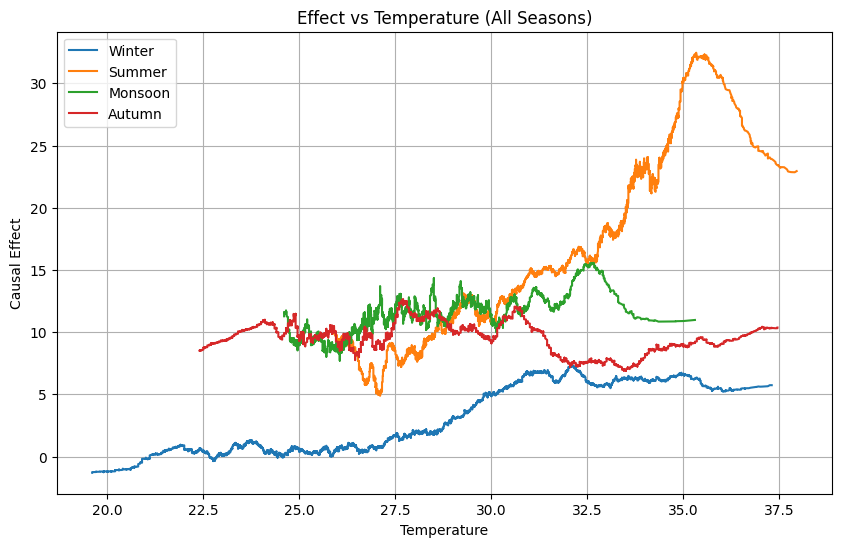

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

for season in seasons:

    df_s = df[df["Season"] == season].copy()
    df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])

    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["temp"].values
    X = df_s[["hour", "rh"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(Y, T, X=X)

    effects = model.effect(X)

    df_s["effect"] = effects
    df_s_sorted = df_s.sort_values("temp")

    df_s_sorted["smooth"] = df_s_sorted["effect"].rolling(200).mean()

    plt.plot(df_s_sorted["temp"], df_s_sorted["smooth"], label=season)

plt.xlabel("Temperature")
plt.ylabel("Causal Effect")
plt.title("Effect vs Temperature (All Seasons)")

plt.legend()
plt.grid()
plt.show()

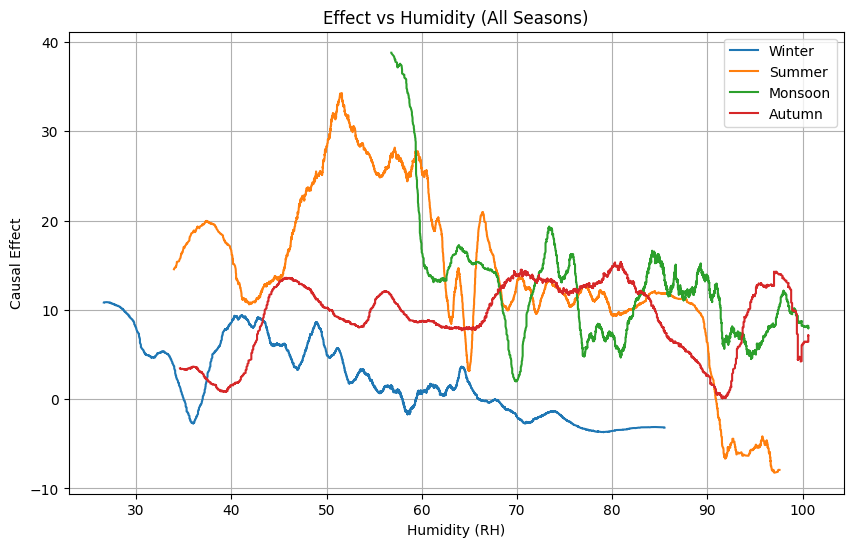

In [23]:
plt.figure(figsize=(10,6))

for season in seasons:

    df_s = df[df["Season"] == season].copy()
    df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])

    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["temp"].values
    X = df_s[["hour", "rh"]].values

    model.fit(Y, T, X=X)

    effects = model.effect(X)

    df_s["effect"] = effects
    df_s_sorted = df_s.sort_values("rh")

    df_s_sorted["smooth"] = df_s_sorted["effect"].rolling(200).mean()

    plt.plot(df_s_sorted["rh"], df_s_sorted["smooth"], label=season)

plt.xlabel("Humidity (RH)")
plt.ylabel("Causal Effect")
plt.title("Effect vs Humidity (All Seasons)")

plt.legend()
plt.grid()
plt.show()

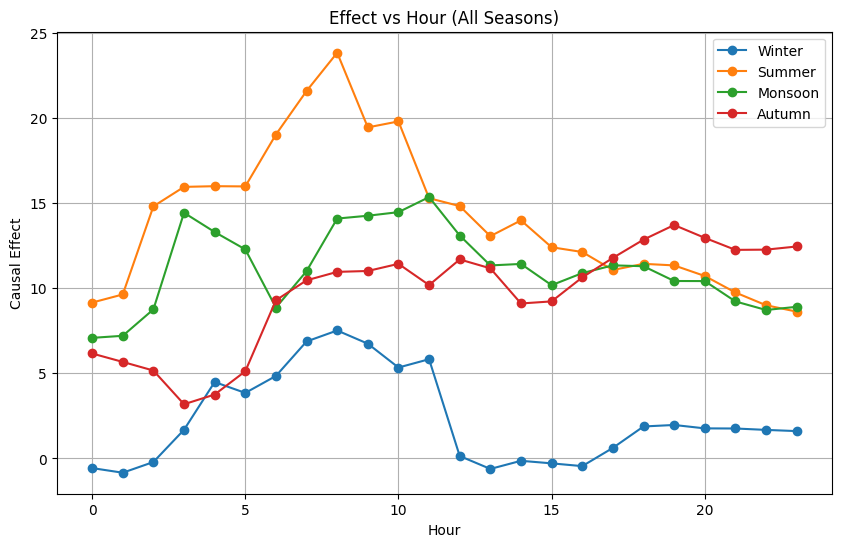

In [24]:
plt.figure(figsize=(10,6))

for season in seasons:

    df_s = df[df["Season"] == season].copy()
    df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])

    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["temp"].values
    X = df_s[["hour", "rh"]].values

    model.fit(Y, T, X=X)

    effects = model.effect(X)

    df_s["effect"] = effects

    hourly_effect = df_s.groupby("hour")["effect"].mean().reset_index()

    plt.plot(hourly_effect["hour"], hourly_effect["effect"], marker='o', label=season)

plt.xlabel("Hour")
plt.ylabel("Causal Effect")
plt.title("Effect vs Hour (All Seasons)")

plt.legend()
plt.grid()
plt.show()